# EarthCARE Quick Look Particle Initialization

This notebook extracts backscatter (BS) and lidar ratio (LR) from EarthCARE Quick Look images [available from JAXA]((https://www.eorc.jaxa.jp/EARTHCARE/Quicklook/index.html)) and generates GIGATRAJ initialization files based on some key features on these images. In a nuyshell

- converts latitude bounds to UTC
- samples fixed launch locations using BS-derived weights
- writes a GigaTraj-compatible NetCDF file,
- and plots the particles in the original decreasing-latitude orientation.

While this code has been developed to operate on Quick Look JPEG images, the code is designed in such way to be extended to work with the actual HDF-5 files containing this data.

It relies on the ``earthcare_particles.py'' module designed by Arlindo da Silva and developed with CODEX assistance during the INSPYRES 2026 deployment.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

from IPython.display import Image

sys.path.insert(0, "../gigatraj")

from earthcare_particles import generate_particles, parse_images, time_bounds


## Inputs and experiment parameters

In [2]:
# Sample files for orbit 12938B
orbit = '12938B'
BS_FILE = Path('./EarthCARE_images/ATL_CLA_cloud_backscatter_1km_20260907_12938B.jpg')
LR_FILE = Path('./EarthCARE_images/ATL_CLA_cloud_lidar_ratio_1km_20260907_12938B.jpg')

TLE_DIRECTORY = './TLE'

## The Case Study
Let's start by looking at two parameters from ATLID Level Quick Look collection: *cloud backscatter* and *cloud lidar ratio*, both at 1 km resolution. In principle, these could also be swaped by the corresponding aerosol products. Here they are:

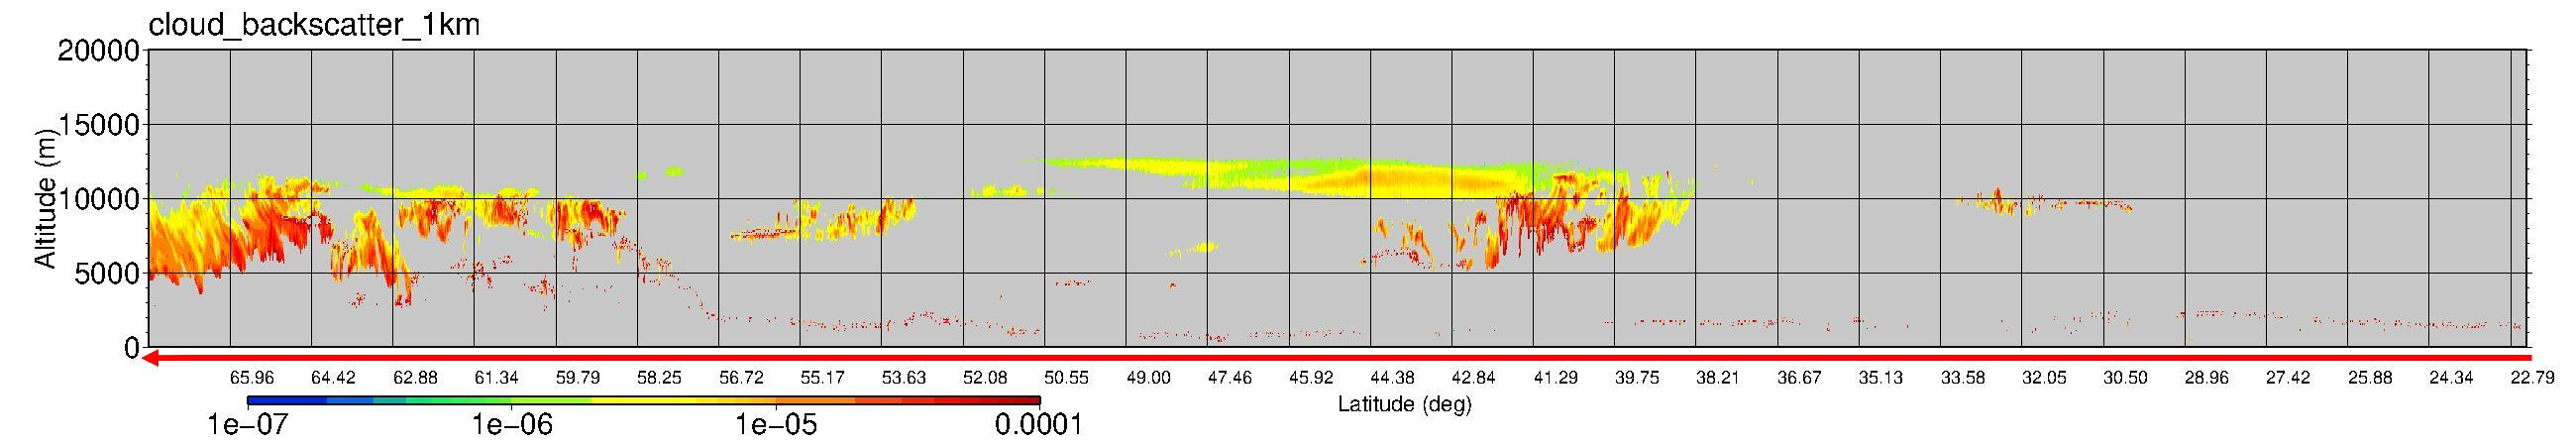

In [3]:
Image(filename=BS_FILE, width=800)

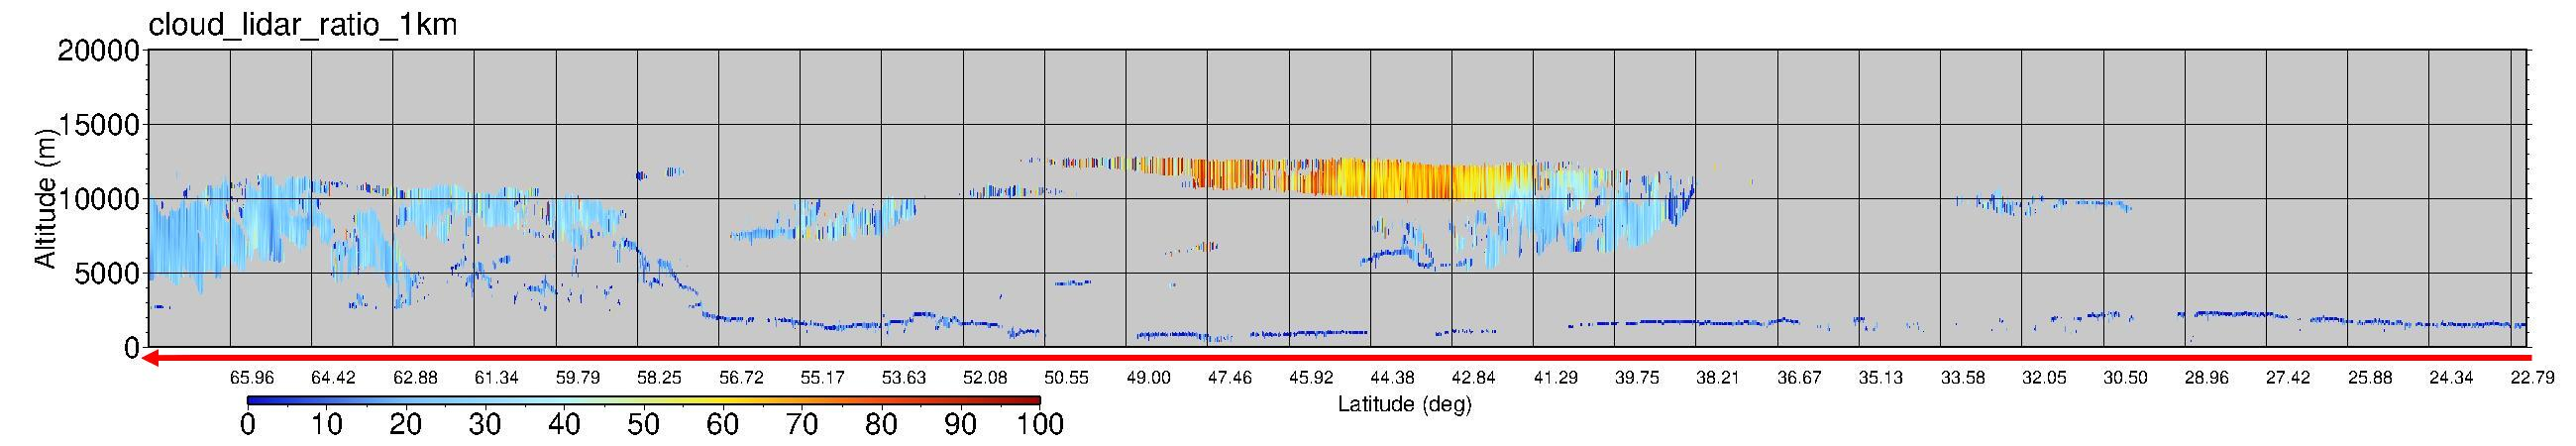

In [4]:
Image(filename=LR_FILE, width=800)

These images come directly from the JAXA Quick Look site, in full resolution (do not do a screenwhot, download the full image.) We are interest at that backscatter feature above 10 km, in between 50.55N and 41.29N which we suspect is smoke from a pyroCB. This defines our bounding box of interest:

## Convert latitude bounds to UTC

The selected orbit-frame segment must be monotonic in latitude. The returned datetimes are timezone-aware UTC values ordered so that `t2 > t1`.

In [13]:
# Latitudinal range (as visually seen on plot) converted to temporal range (needed internally)
# --------------------------------------------------------------------------------------------
lat1, lat2 = 50.55, 41.29  # found by visually inspecting image 
t1, t2 = time_bounds(lat1,lat2,orbit,tle_directory=TLE_DIRECTORY,)
print("UTC bounds:", t1.isoformat(timespec='minutes'),' to ',t2.isoformat(timespec='minutes'))

UTC bounds: 2026-09-07T10:52+00:00  to  2026-09-07T10:54+00:00


## Extract Backscatter and Lidar Ratio

While we will eventually be doing this step using the HDF-5 Level 2 data files, during an airborne campaign because of network bandwidth and/or other constraints the Quick Looks is what we often have conveniently available. The goal here is to automate an otherwise time consuming manual task. To this end, the parser below calibrates the image axes and color bars, removes plotted grid-line artifacts, and returns aligned `xarray.DataArray` objects on UTC-time and altitude coordinates.

In [6]:
bs, lr = parse_images([BS_FILE, LR_FILE], orbit, tle_directory=TLE_DIRECTORY)
display(bs)
display(lr)

<xarray.DataArray 'bs' (altitude: 299, time: 2399)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(299, 2399))
Coordinates:
  * altitude   (altitude) float64 2kB 0.0 0.06711 0.1342 ... 19.87 19.93 20.0
  * time       (time) datetime64[ns] 19kB 2026-09-07T10:47:35.515547904 ... 2...
    longitude  (time) float64 19kB -135.2 -135.2 -135.2 ... -152.5 -152.5 -152.5
    latitude   (time) float64 19kB 22.5 22.52 22.54 22.56 ... 67.46 67.48 67.5
Attributes:
    orbit:        12938
    frame:        B
    orbit_frame:  12938B
    source_kind:  quick-look image
    long_name:    backscatter
    source:       EarthCARE_images/ATL_CLA_cloud_backscatter_1km_20260907_129...
    color_scale:  logarithmic

<xarray.DataArray 'lr' (altitude: 299, time: 2399)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(299, 2399))
Coordinates:
  * altitude   (altitude) float64 2kB 0.0 0.06711 0.1342 ... 19.87 19.93 20.0
  * time       (time) datetime64[ns] 19kB 2026-09-07T10:47:35.515547904 ... 2...
    longitude  (time) float64 19kB -135.2 -135.2 -135.2 ... -152.5 -152.5 -152.5
    latitude   (time) float64 19kB 22.5 22.52 22.54 22.56 ... 67.46 67.48 67.5
Attributes:
    orbit:        12938
    frame:        B
    orbit_frame:  12938B
    source_kind:  quick-look image
    long_name:    lidar ratio
    source:       EarthCARE_images/ATL_CLA_cloud_lidar_ratio_1km_20260907_129...
    color_scale:  linear

## Using Lidar Ratio and Depolarization as Filters

The cloud lidar ratio is
$$
S = { \alpha \over \beta}
$$
where $\alpha$ is extinction and $\beta$ is backscatter. It describes how much attenuation is associated with a given amount of light returned to the lidar. Ice-cloud lidar ratio depends on crystal habit, size, orientation, and optical thickness. A relatively low/moderate cloud lidar ratio is compatible with cirrus and other ice-cloud particle populations. 

Depolarization is the more decisive indication of non-sphericity and can also be used to discriminate ice crystals, although nin-spherical smoke can also depolarize.

The variability in both fields could reflect real microphysical variation across the cloud, retrieval uncertainty in weak portions of the layer, or both. The ATLID L2a retrieval uses lidar ratio and depolarization as complementary optical properties; when a quantitative lidar ratio cannot be retrieved robustly, retrieval processing can use class-dependent a priori values. Thus, values should be interpreted together with the feature/target mask and extinction/backscatter fields, especially near cloud boundaries or in tenuous returns

For this example we will only consider the lidar ratio in connection with a specific feature. It shoukld suffice to demonstrate the approach and how to use this software.  Notice that while we suspect the feature of interest is associated pyroCB smoke, EarthCARE's algorithm classified it as clouds. Therefore, we are using *cloud* backscatter and lidar ratio.


## Generating Particle Locations for Trajectory analysis

This example uses the strict condition `LR > 50` to filter out potential cirrus clouds. Values not satisfying that condition are made invalid before calling `generate_particles`. The function uses the sampled orbital times internally to interpolate longitude and latitude, but the output contains a single trajectory-launch time record.

Notice that the cloud backscatter parameter is used as proxy for the (non-normalized) particle probability density. Particle concentrations are made proportional to $\beta$.


In [8]:
# Example parameters
# ------------------
z1, z2 = 10.0, 15.0   # vertical range, see above for latitudinal range
lr_threshold = 50.0   # will only keep pixels with lidar ratio greater than 50.
N = 2500              # Number of particles to setup
random_seed = 12938   # For reproducibility

# Mask out according to Lidar Ratio (could also use depolarization ratio) 
# -----------------------------------------------------------------------
mask = lr > lr_threshold #  Keep only points that satisfy this condition

# Calculate the particle locations
# --------------------------------
particles = generate_particles(bs, mask, N, bounds=(t1, t2, z1, z2), seed=random_seed,)
display(particles)

<xarray.Dataset> Size: 50kB
Dimensions:  (time: 1, id: 2500)
Coordinates:
  * time     (time) float64 8B 0.0
  * id       (id) float64 20kB 0.0 1.0 2.0 3.0 ... 2.497e+03 2.498e+03 2.499e+03
Data variables:
    lon      (time, id) float32 10kB -140.2 -140.6 -141.1 ... -140.0 -140.5
    lat      (time, id) float32 10kB 42.86 44.27 45.86 ... 42.53 42.36 44.11
    PAlt     (time, id) float32 10kB 10.97 11.36 10.61 ... 11.33 10.38 11.78
Attributes:
    Contents:            gigatraj trajectories
    Trajectory_start:    0
    source_orbit_frame:  12938B
    probability_proxy:   bs
    P_mean:              4.483539548835155e-06
    random_seed:         12938

## Validate Particle Locations and write NetCDF for GIGATRAJ

In [16]:
import gigatraj as pygt

# Validate Results
# ----------------
assert particles.sizes == {'time': 1, 'id': N}
assert float(particles.PAlt.min()) >= z1
assert float(particles.PAlt.max()) <= z2
assert float(particles.lat.min()) >= min(lat1, lat2)
assert float(particles.lat.max()) <= max(lat1, lat2)

# Get GIGATRAJ scratch directory
# ------------------------------
gt = pygt.GIGATRAJ()
SCRATCH = gt.cf['SCRATCH']

# Write out GIGATRAJ compatible "parcel initialization" file
# ----------------------------------------------------------
OUTPUT_FILE = Path(f'{SCRATCH}/parcel_init.EarthCARE_12938B.10km.nc') # Follows file name conventions
particles.to_netcdf(OUTPUT_FILE)
print(f'Saved {OUTPUT_FILE}')

Saved /shared/users-local/adasilva/data/SCRATCH/gigatraj/parcel_init.EarthCARE_12938B.10km.nc


## Latitude–height Diagnostic Plot

The latitude axis decreases from left to right to reproduce the original EarthCARE quick-look orientation. The BS field is shown over the full image extent, while the dashed rectangle marks the particle-sampling domain.

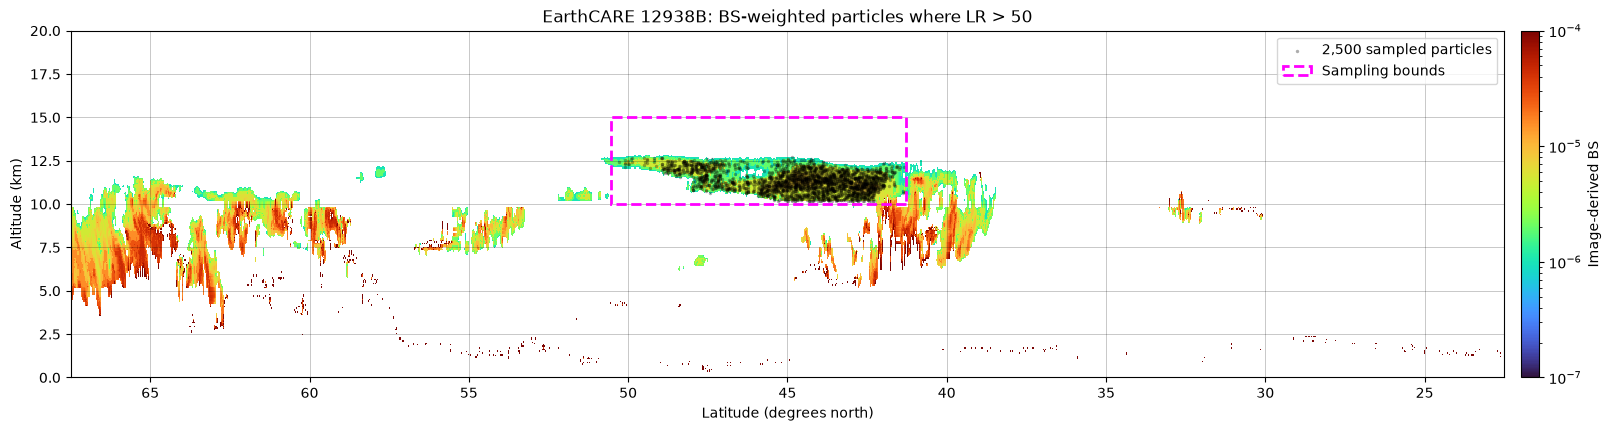

In [10]:
fig, ax = plt.subplots(figsize=(16, 4.2), constrained_layout=True)

mesh = ax.pcolormesh(
    bs.latitude,
    bs.altitude,
    bs,
    shading='auto',
    cmap='turbo',
    norm=LogNorm(vmin=1e-7, vmax=1e-4),
)
ax.scatter(
    particles.lat.values[0],
    particles.PAlt.values[0],
    s=6,
    color='black',
    alpha=0.32,
    linewidths=0,
    label=f'{N:,} sampled particles',
    zorder=4,
)
ax.add_patch(
    Rectangle(
        (min(lat1, lat2), z1),
        abs(lat2 - lat1),
        z2 - z1,
        fill=False,
        edgecolor='magenta',
        linewidth=2,
        linestyle='--',
        label='Sampling bounds',
        zorder=5,
    )
)

ax.set_xlim(float(bs.latitude.max()), float(bs.latitude.min()))
ax.set_ylim(0, 20)
ax.set_xlabel('Latitude (degrees north)')
ax.set_ylabel('Altitude (km)')
ax.set_title(
    f'EarthCARE {orbit}: BS-weighted particles where '
    f'LR > {lr_threshold:g}'
)
ax.grid(color='black', alpha=0.25, linewidth=0.6)
ax.legend(loc='upper right')
colorbar = fig.colorbar(mesh, ax=ax, pad=0.012)
colorbar.set_label('Image-derived BS')
plt.show()

Notice the concentration of black dots (particle locations) where the backscatter is the largest.

## Generate Trajectories with GIGATRAJ
Since we saved the initial locations to the standard place (according to `gigatraj.yaml` we can now generate trajectories. For this purpose, we created a fake fire called EarthCARE_12938B.

Note: This does not work on Jupyter hub on the Airborne SMCE.

In [18]:
# gt.genTrajectories()